<a href="https://colab.research.google.com/github/giolanta-nta/Homework/blob/main/%CE%91%CE%BD%CF%84%CE%AF%CE%B3%CF%81%CE%B1%CF%86%CE%BF_Classwork4_Beers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Μπύρες & Ζυθοποιεία

##  Εισάγετε τις βιβλιοθήκες που θα χρειαστείτε

In [ ]:
import pandas as pd
%matplotlib inline

## Εισάγετε το αρχείο `craftcans.csv`, από τον φάκελο data και κοιτάξτε τις πρώτες γραμμές

**βοήθεια** οι κενές γραμμές, δηλαδή οι τιμές NaN του συγκεκριμένου αρχείου είναι na_values = ["???", "Unknown", "UNKNOWN"]

In [ ]:
df= pd.read_csv("https://raw.githubusercontent.com/datajour-gr/Data_journalism/refs/heads/master/week4/craftcans.csv", na_values = ["???", "Unknown", "UNKNOWN"])


## Πόσες γραμμές έχει το αρχείο? Τι τύπος είναι οι στήλες?

In [ ]:
df.shape

(2416, 7)

In [ ]:
df.head()

,Beer,Brewery,Location,Style,Size,ABV,IBUs
0,Get Together,NorthGate Brewing,"Minneapolis, MN",American IPA,16 oz.,4.50%,50.0
1,Maggie's Leap,NorthGate Brewing,"Minneapolis, MN",Milk / Sweet Stout,16 oz.,4.90%,26.0
2,Wall's End,NorthGate Brewing,"Minneapolis, MN",English Brown Ale,16 oz.,4.80%,19.0
3,Pumpion,NorthGate Brewing,"Minneapolis, MN",Pumpkin Ale,16 oz.,6.00%,38.0
4,Stronghold,NorthGate Brewing,"Minneapolis, MN",American Porter,16 oz.,6.00%,25.0


In [ ]:
df.dtypes

,0
Beer,object
Brewery,object
Location,object
Style,object
Size,object
ABV,object
IBUs,float64


# Ανάλυση ζυθοποιείων


## Ποιοι είναι οι top 10 παραγωγοί μπύρας?

In [ ]:
df['Brewery'].value_counts(ascending = False)[0:9]

,count
Brewery,
Brewery Vivant,62
Oskar Blues Brewery,46
Sun King Brewing Company,38
Cigar City Brewing Company,25
Sixpoint Craft Ales,24
Hopworks Urban Brewery,23
Stevens Point Brewery,22
21st Amendment Brewery,20
Great Crescent Brewery,20


## Ποιο είναι το πιο κοινό μέγεθος μπύρας?


In [ ]:
df['Size'].value_counts(ascending = False)

,count
Size,
12 oz.,1507
16 oz.,814
24 oz.,21
16 oz. Alumi-Tek®,15
19.2 oz.,14
12 oz,14
16 oz,12
32 oz.,5
12 oz. Slimline,1


In [ ]:
df[df['Size']== '16 oz.']


,Beer,Brewery,Location,Style,Size,ABV,IBUs
0,Get Together,NorthGate Brewing,"Minneapolis, MN",American IPA,16 oz.,4.50%,50.0
1,Maggie's Leap,NorthGate Brewing,"Minneapolis, MN",Milk / Sweet Stout,16 oz.,4.90%,26.0
2,Wall's End,NorthGate Brewing,"Minneapolis, MN",English Brown Ale,16 oz.,4.80%,19.0
3,Pumpion,NorthGate Brewing,"Minneapolis, MN",Pumpkin Ale,16 oz.,6.00%,38.0
4,Stronghold,NorthGate Brewing,"Minneapolis, MN",American Porter,16 oz.,6.00%,25.0
...,...,...,...,...,...,...,...
2402,Bender,Surly Brewing Company,"Brooklyn Center, MN",American Brown Ale,16 oz.,5.10%,45.0
2403,Abrasive Ale,Surly Brewing Company,"Brooklyn Center, MN",American Double / Imperial IPA,16 oz.,9.70%,120.0
2404,Hell,Surly Brewing Company,"Brooklyn Center, MN",Keller Bier / Zwickel Bier,16 oz.,5.10%,20.0
2405,CynicAle,Surly Brewing Company,"Brooklyn Center, MN",Saison / Farmhouse Ale,16 oz.,6.70%,33.0


In [ ]:
import statistics

In [ ]:
round(df[df['Size']== '16 oz.']['IBUs'].mean())

45

In [ ]:
df.groupby(by='Location')['IBUs'].mean().sort_values(ascending=False).head(3)

,IBUs
Location,
"Abingdon, VA",135.0
"Virginia Beach, VA",108.0
"Export, PA",100.0


In [ ]:
max IBUs σε κάθε location

In [ ]:
df.groupby('Location')['IBUs'].max(3).sort_values(ascending=False).head(3)

,IBUs
Location,
"Astoria, OR",138.0
"Abingdon, VA",135.0
"Gloucester, MA",130.0


## Ποιο είναι το πιο συνηθισμένο ποσοστό αλκοόλ (ABV -  alcohol by volume)?


In [ ]:
df['ABV'].value_counts(ascending = False)

,count
ABV,
5.00%,215
5.50%,158
6.00%,125
6.50%,123
5.20%,107
...,...
10.00%,1
2.80%,1
9.40%,1


## Όπως βλέπετε το ABV δεν είναι αριθμός. Μετατρέψτε το σε αριθμό.

3 βήματα:

1. Επιλέξτε την στήλη ABV
2. Αφαιρέστε το σύμβολο % (**βοήθεια** μετατρέψτε το σε κενό)
3. Μετατρέψτε την στήλη τώρα σε `float`
4. Μπορείτε να την σώσετε με ένα νέο column ή στο ίδιο.  

Σε περίπτωση που όταν εισάγατε το αρχείο δεν ορίσατε ποια είναι τα κενά δεδομένα (nan) τότε ήρθε η ώρα να τα καθαρίσετε.

In [ ]:
df['ABV'].str.replace('%', '').astype(float)
df['ABVS'] = df['ABV'].str.replace('%', '').astype(float)

In [ ]:
df['ABV'].str.replace('%', '').astype(float)

,ABV
0,4.5
1,4.9
2,4.8
3,6.0
4,6.0
...,...
2411,5.3
2412,9.9
2413,8.0
2414,8.7


In [ ]:
df['ABV']

,ABV
0,4.50%
1,4.90%
2,4.80%
3,6.00%
4,6.00%
...,...
2411,5.30%
2412,9.90%
2413,8.00%
2414,8.70%


In [ ]:
df['ABVS']

,ABVS
0,4.5
1,4.9
2,4.8
3,6.0
4,6.0
...,...
2411,5.3
2412,9.9
2413,8.0
2414,8.7


# Περιοχές


## Ποιες είναι οι top 10 πόλεις των ΗΠΑ σε παραγωγή μπύρας?

In [ ]:
df['Location'].value_counts().head(10)

,count
Location,
"Grand Rapids, MI",66
"Chicago, IL",55
"Portland, OR",52
"Indianapolis, IN",43
"San Diego, CA",42
"Boulder, CO",41
"Denver, CO",40
"Brooklyn, NY",38
"Seattle, WA",35


## Βρείτε όλα τα ζυθοποιεία στο Brooklyn, NY

In [ ]:
#Με τον παρακάτω τρόπο μπορούμε να ζητήσουμε όσες γραμμές είναι ίσες με Brooklyn,
# και να μας δείξει και την στήλη που ψάχνουμε δίπλα βάζοντας την μέσα σε [ ]
df[df['Location'] == 'Brooklyn, NY']['Beer']

,Beer
115,4Beans
210,Jammer
246,Abigale
404,Nomader Weiss
421,Rad
439,Molotov Lite
588,Bengali
713,Sensi Harvest
969,Hi-Res
987,KelSo Nut Brown Lager


## Ποιο ζυθοποιείο στο Brooklyn έχει τη μεγαλύτερη παραγωγή?

In [ ]:
df[df['Location'] == 'Brooklyn, NY']['Brewery'].value_counts()

,count
Brewery,
Sixpoint Craft Ales,24
Brooklyn Brewery,6
Evil Twin Brewing,5
KelSo Beer Company,3


## Ποια είναι τα 5 δημοφιλέστερα είδη μπύρας που παράγει η Sixpoint?

In [ ]:
df[df['Brewery'] == 'Sixpoint Craft Ales']['Style'].value_counts().head(5)

,count
Style,
American IPA,4
Baltic Porter,2
American Double / Imperial IPA,2
German Pilsener,2
Cream Ale,2


## Βρείτε όλα τα ζυθοποιεία στην Νέα Υόρκη και μετά μετρήστε τα.

In [ ]:
NY = df[df['Location'].str.contains("NY", na=False)]
NY['Location'].value_counts()

,count
Location,
"Brooklyn, NY",38
"Utica, NY",13
"Patchogue, NY",4
"Garrattsville, NY",4
"New York, NY",3
"Bronx, NY",3
"Chatham, NY",2
"Montauk, NY",2
"Elmira, NY",2


# Μέτρηση πικράδας!  

Η μονάδα μέτρησης IBU σημαίνει [International Bitterness Unit](http://www.thebrewenthusiast.com/ibus/), συνήθως οι ζυθοποιοί καμαρώνουν όταν έχουν πικρή μπύρα!


## Ποιος είναι ο μέσος όρος IBU σε όλες τις μπύρες?

In [ ]:
df['IBUs'].describe()

,IBUs
count,1405.000000
mean,42.713167
std,25.954066
min,4.000000
25%,21.000000
50%,35.000000
75%,64.000000
max,138.000000


## Φτάξτε ένα γράφημα διασποράς (histogram  στην python hist) για το IBU και όταν ορίσετε το ιστόγραμμα βάλτε  *30* bins αντί για το default που είναι 10

In [ ]:
%matplotlib inline

<Axes: ylabel='Frequency'>

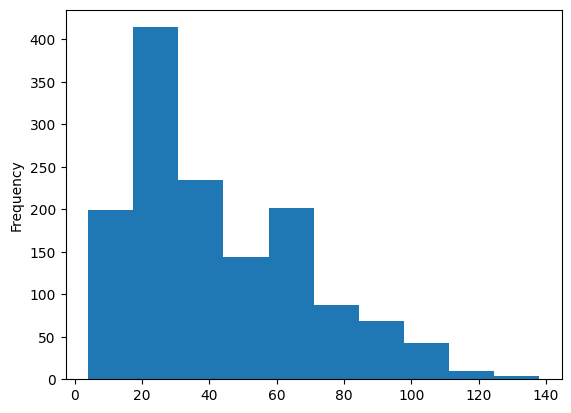

In [ ]:
df['IBUs'].plot.hist(bins= 10)

## Βρείτε όλες τις μπύρες που το IBU βρίσκεται στο 75ο εκατοστημόριο.

**βοήθεια**: κάντε describe για να βρείτε το νούμερο

In [ ]:
df[df['IBUs'] > 64.000000]['Beer']

,Beer
6,Citra Ass Down
7,London Balling
14,Rico Sauvin
17,Pile of Face
21,Excess IPL
...,...
2408,Brew Free! or Die IPA
2410,Ten Fidy Imperial Stout
2412,GUBNA Imperial IPA
2414,Gordon Ale (2009)


## Βρείτε όλες τις μπύρες που το IBU βρίσκεται κάτω από το 25ο εκατοστημόριο.

In [ ]:
df[df['IBUs'] < 21.000000]['Beer']

2                                   Wall's End
12                                    Sho'nuff
13                                 Bloody Show
18                              The Brown Note
19                                 House Lager
20                                Leisure Time
30                                        Park
31                                   Westfalia
32                                         KSA
54                                     Sparkle
56                                Hotbox Brown
57                                        Gold
66                                  Cafe Leche
67                      Damascene Apricot Sour
90                                 Sex Panther
102                             Vanilla Porter
105                                       Gose
106                            Vermont Pilsner
134                        Ginger Peach Saison
139                              Weissenheimer
144                      Passion Fruit Prussia
145          

## Βρείτε τη διάμεσο (median) του IBU για κάθε είδος μπύρας. Στην συνέχει φτιάξτε ένα γράφημα γιαυτό.

Βάλτε τα μεγάλα στο επάνω μέρος, και τα nan στο τέλος. Για να είναι όμορφο το γράφημα δεν πρέπει να εμφανίζονται το ένα πάνω στο άλλο γιαυτό μεγαλώστε το μέγεθός του με το figsize=(2,15)

In [ ]:
df.dropna(subset=['Size'])

,Beer,Brewery,Location,Style,Size,ABV,IBUs,ABVS
0,Get Together,NorthGate Brewing,"Minneapolis, MN",American IPA,16 oz.,4.50%,50.0,4.5
1,Maggie's Leap,NorthGate Brewing,"Minneapolis, MN",Milk / Sweet Stout,16 oz.,4.90%,26.0,4.9
2,Wall's End,NorthGate Brewing,"Minneapolis, MN",English Brown Ale,16 oz.,4.80%,19.0,4.8
3,Pumpion,NorthGate Brewing,"Minneapolis, MN",Pumpkin Ale,16 oz.,6.00%,38.0,6.0
4,Stronghold,NorthGate Brewing,"Minneapolis, MN",American Porter,16 oz.,6.00%,25.0,6.0
...,...,...,...,...,...,...,...,...
2411,Mama's Little Yella Pils,Oskar Blues Brewery,"Longmont, CO",Czech Pilsener,12 oz.,5.30%,35.0,5.3
2412,GUBNA Imperial IPA,Oskar Blues Brewery,"Longmont, CO",American Double / Imperial IPA,12 oz.,9.90%,100.0,9.9
2413,Old Chub,Oskar Blues Brewery,"Longmont, CO",Scottish Ale,12 oz.,8.00%,35.0,8.0
2414,Gordon Ale (2009),Oskar Blues Brewery,"Longmont, CO",American Double / Imperial IPA,12 oz.,8.70%,85.0,8.7


In [ ]:
import numpy as np

In [ ]:
df[df[['Size', 'Location']].isnull()]

,Beer,Brewery,Location,Style,Size,ABV,IBUs,ABVS
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
2411,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2412,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2413,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2414,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: ylabel='Style'>

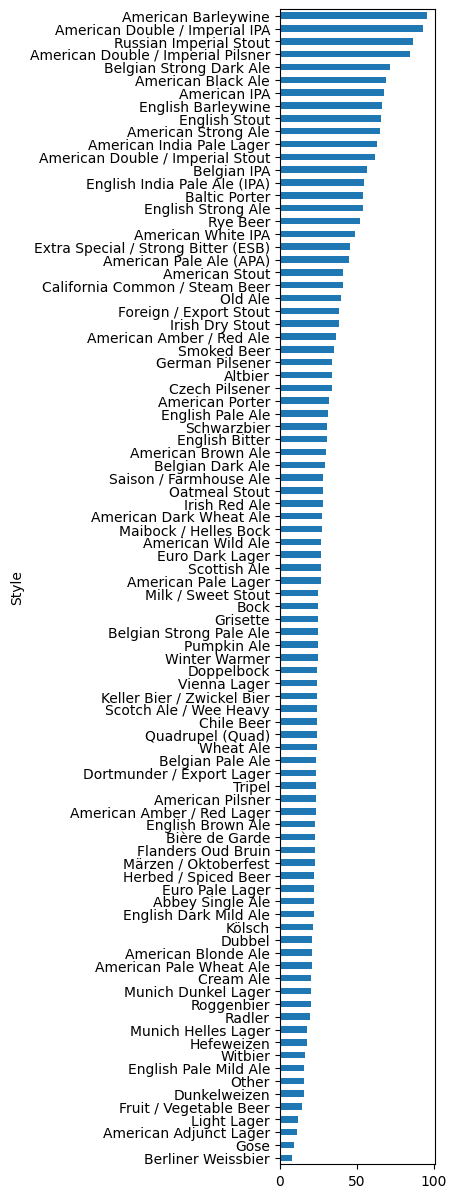

In [ ]:
df.groupby('Style')['IBUs'].mean().dropna().sort_values(ascending=True).plot(kind = 'barh', figsize=(2,15))

## Βλέπουμε ότι υπάρχουν πολά είδη μπύρας, ποια είναι όμως τα 5 δημοφιλέστερα χαμηλά σε πικράδα και ποια τα υψηλά (high-IBU vs. low-IBU)?

Πρώτα βρείτε ποια έχουν high IBU, μετά βρείτε τα δημοφιλέστερα από αυτά και μετά πάρτε τα πρώτα 5.

In [ ]:
High = df[df['IBUs'] > 64.000000]

In [ ]:
High['Style'].value_counts().head(5)

,count
Style,
American IPA,195
American Double / Imperial IPA,72
American Pale Ale (APA),18
American Black Ale,15
American Strong Ale,9


## Βρείτε τον μέσο όρο IBU για τις μπύρες "Witbier", "Hefeweizen" και "American Pale Wheat Ale" και μετά φτιάξτε ένα ιστόγραμμα.

Θέλουμε μόνο ένα γράφημα, που να δείχνει όλα τα παραπάνω! Και δοκιμάστε ξανά στο ιστόγραμμα να έχετε 20-30 bins.

In [ ]:
df[(df['Style'] == 'Witbier') | (df['Style'] =='Hefeweizen') | (df['Style'] =='American Pale Wheat Ale')]

,Beer,Brewery,Location,Style,Size,ABV,IBUs,ABVS
30,Park,Fort Point Beer Company,"San Francisco, CA",American Pale Wheat Ale,12 oz.,4.70%,19.0,4.7
42,Whitewater,Great Divide Brewing Company,"Denver, CO",American Pale Wheat Ale,12 oz.,6.10%,NaN,6.1
72,Citra Faced,Three Pints Brewing,"Martinsville, IN",American Pale Wheat Ale,16 oz.,5.50%,64.0,5.5
112,Summer Wheat,Anchor Brewing Company,"San Francisco, CA",American Pale Wheat Ale,12 oz.,4.50%,NaN,4.5
138,Waterkeeper,SweetWater Brewing Company,"Atlanta, GA",Hefeweizen,12 oz.,5.70%,NaN,5.7
...,...,...,...,...,...,...,...,...
2334,Haywire Hefeweizen (2010),Pyramid Breweries,"Seattle, WA",Hefeweizen,16 oz.,5.20%,18.0,5.2
2344,Sunshine Wheat Beer (2009),New Belgium Brewing Company,"Fort Collins, CO",American Pale Wheat Ale,12 oz.,4.80%,NaN,4.8
2364,Heinnieweisse Weissebier,Butternuts Beer and Ale,"Garrattsville, NY",Hefeweizen,12 oz.,4.90%,NaN,4.9
2383,Montana Trout Slayer Ale (2009),Big Sky Brewing Company,"Missoula, MT",American Pale Wheat Ale,12 oz.,5.00%,35.0,5.0


In [ ]:
beers = ["Witbier", "Hefeweizen", "American Pale Wheat Ale"]
StyleNew = df[df['Style'].isin(beers)].dropna()

In [ ]:
beers = ["Witbier", "Hefeweizen", "American Pale Wheat Ale"]

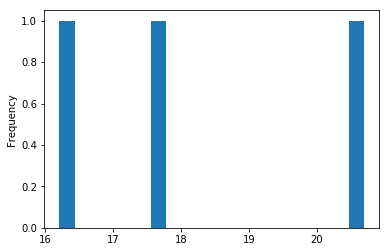

In [ ]:
StyleNew.groupby('Style')['IBUs'].mean().plot.hist(by="IBUs", bins= 20)

## Βρείτε το μέσο όρο IBU για το είδος "IPA" και φτιάξτε ένα ιστόγραμμα.

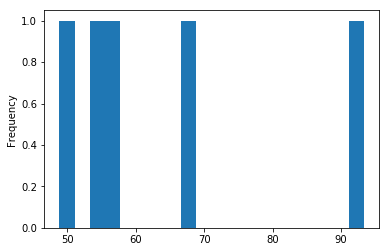

In [ ]:
IPA = df[df['Style'].str.contains("IPA", na=False)].dropna()
IPA.groupby('Style')['IBUs'].mean().plot.hist(by="IBUs", bins= 20)

## Κάντε ένα γράφημα και με τα 2 παραπάνω ιστογράμματα.

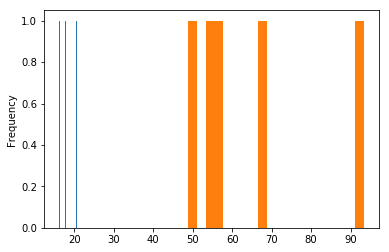

In [ ]:
ax = StyleNew.groupby('Style')['IBUs'].mean().plot.hist(by="IBUs", bins= 20)
IPA.groupby('Style')['IBUs'].mean().plot.hist(by="IBUs", bins= 20,ax=ax)

## Συγκρίνετε το ABV από τις μπύρες που γίνονται από σιτάρι ( wheat ) σε σχέση με τις IPAs. Αν τα καταφέρετε, φτιάξτε και ένα γράφημα!

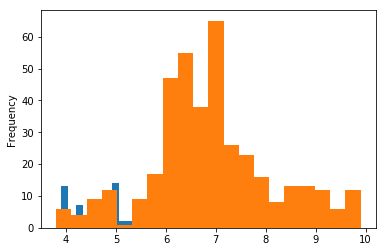

In [ ]:
wheat = df[df['Style'].str.contains("Wheat", na=False)].dropna()
ax = wheat['ABVS'].plot.hist(by="ABVS", bins= 20)
IPA['ABVS'].plot.hist(by="ABVS", bins= 20,ax=ax)